# Sprint 0  :  Setup & Audit Initial du Dataset

**AquaSense AI  -  EHTP MIG S4**

Ce notebook valide :
- La présence des fichiers CSV dans `data/raw/`
- Les dimensions du dataset (59 400 × 40 attendues)
- Les types de colonnes et un aperçu des données
- La distribution de la variable cible `status_group`

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

PROJECT_ROOT = Path("..").resolve()
RAW_DIR = PROJECT_ROOT / "data" / "raw"

print(f"Racine projet : {PROJECT_ROOT}")
print(f"Dossier raw   : {RAW_DIR}")

Racine projet : C:\Users\MOH\Documents\AquaSense_AI
Dossier raw   : C:\Users\MOH\Documents\AquaSense_AI\data\raw


## 1. Vérification des fichiers

In [2]:
REQUIRED_FILES = ["train_values.csv", "train_labels.csv", "test_values.csv"]

for fname in REQUIRED_FILES:
    fpath = RAW_DIR / fname
    if fpath.exists():
        size_mb = fpath.stat().st_size / (1024 * 1024)
        print(f"Oui {fname}  :  {size_mb:.2f} Mo")
    else:
        print(f"Non {fname}  :  MANQUANT (lancer: python scripts/download_data.py)")

Oui train_values.csv  :  19.14 Mo
Oui train_labels.csv  :  1.10 Mo
Oui test_values.csv  :  4.78 Mo


## 2. Chargement des données

In [3]:
train_values = pd.read_csv(RAW_DIR / "train_values.csv")
train_labels = pd.read_csv(RAW_DIR / "train_labels.csv")
test_values = pd.read_csv(RAW_DIR / "test_values.csv")

print("train_values :", train_values.shape)
print("train_labels :", train_labels.shape)
print("test_values  :", test_values.shape)

train_values : (59400, 40)
train_labels : (59400, 2)
test_values  : (14850, 40)


## 3. Validation des dimensions (critère S0)

In [4]:
EXPECTED_ROWS = 59_400
EXPECTED_COLS = 40

assert train_values.shape[0] == EXPECTED_ROWS, f"Lignes: {train_values.shape[0]} != {EXPECTED_ROWS}"
assert train_values.shape[1] == EXPECTED_COLS, f"Colonnes: {train_values.shape[1]} != {EXPECTED_COLS}"
assert train_labels.shape[0] == EXPECTED_ROWS

print(f"Oui Dimensions validées : {EXPECTED_ROWS} lignes × {EXPECTED_COLS} colonnes")

Oui Dimensions validées : 59400 lignes × 40 colonnes


## 4. Types et aperçu

In [5]:
print("=== dtypes ===")
print(train_values.dtypes.value_counts())
print("\n=== head ===")
train_values.head()

=== dtypes ===
object     30
int64       7
float64     3
Name: count, dtype: int64

=== head ===


,id,amount_tsh,date_recorded,funder,gps_height,installer,longitude,latitude,wpt_name,num_private,...,payment_type,water_quality,quality_group,quantity,quantity_group,source,source_type,source_class,waterpoint_type,waterpoint_type_group
0,69572,6000.0,2011-03-14,Roman,1390,Roman,34.938093,-9.856322,none,0,...,annually,soft,good,enough,enough,spring,spring,groundwater,communal standpipe,communal standpipe
1,8776,0.0,2013-03-06,Grumeti,1399,GRUMETI,34.698766,-2.147466,Zahanati,0,...,never pay,soft,good,insufficient,insufficient,rainwater harvesting,rainwater harvesting,surface,communal standpipe,communal standpipe
2,34310,25.0,2013-02-25,Lottery Club,686,World vision,37.460664,-3.821329,Kwa Mahundi,0,...,per bucket,soft,good,enough,enough,dam,dam,surface,communal standpipe multiple,communal standpipe
3,67743,0.0,2013-01-28,Unicef,263,UNICEF,38.486161,-11.155298,Zahanati Ya Nanyumbu,0,...,never pay,soft,good,dry,dry,machine dbh,borehole,groundwater,communal standpipe multiple,communal standpipe
4,19728,0.0,2011-07-13,Action In A,0,Artisan,31.130847,-1.825359,Shuleni,0,...,never pay,soft,good,seasonal,seasonal,rainwater harvesting,rainwater harvesting,surface,communal standpipe,communal standpipe


## 5. Distribution de la cible

                         count   pct
status_group                        
functional               32259  54.3
non functional           22824  38.4
functional needs repair   4317   7.3


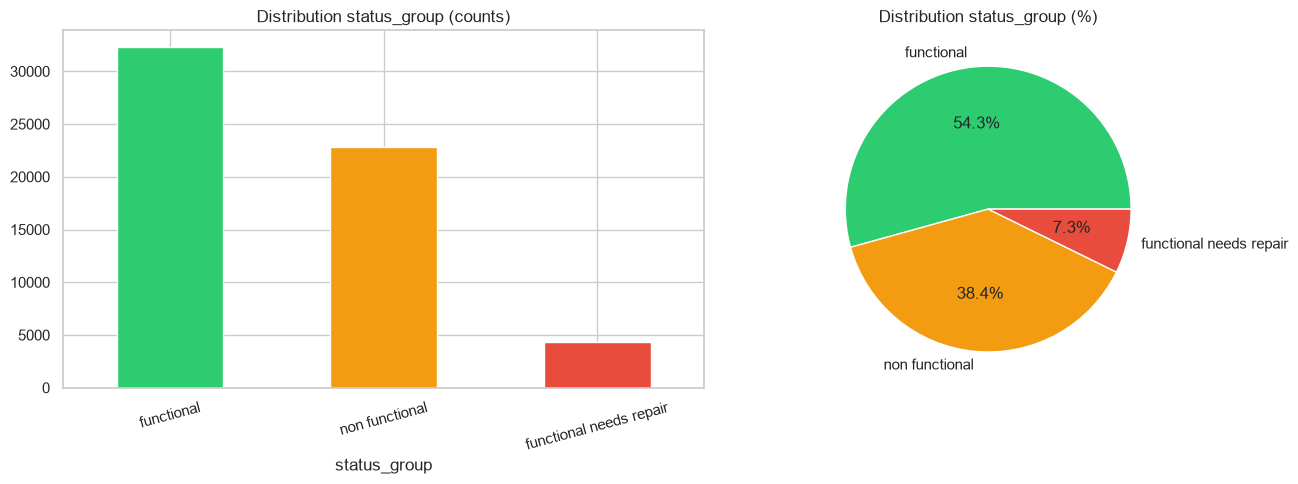

In [6]:
target_counts = train_labels["status_group"].value_counts()
target_pct = train_labels["status_group"].value_counts(normalize=True) * 100

summary = pd.DataFrame({"count": target_counts, "pct": target_pct.round(1)})
print(summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
target_counts.plot.bar(ax=axes[0], color=["#2ecc71", "#f39c12", "#e74c3c"])
axes[0].set_title("Distribution status_group (counts)")
axes[0].tick_params(axis="x", rotation=15)
target_pct.plot.pie(ax=axes[1], autopct="%.1f%%", colors=["#2ecc71", "#f39c12", "#e74c3c"])
axes[1].set_title("Distribution status_group (%)")
axes[1].set_ylabel("")
plt.tight_layout()
plt.show()

## 6. Résumé audit initial

| Élément | Valeur attendue | Statut |
|---------|-----------------|--------|
| train_values shape | (59400, 40) | À confirmer ci-dessus |
| Classes cible | 3 | functional / needs repair / non functional |
| Imbalance | ~54% / ~7% / ~39% | À confirmer ci-dessus |